<a href="https://colab.research.google.com/github/jensjose07/deep_learning_lab/blob/main/experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0410
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0422
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0191
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0126
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0085
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0073
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041
Epoch 12/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042
Epoch 13/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038
Epoch 14/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038
Epoch 15/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038
Epoch 16/50
68/68

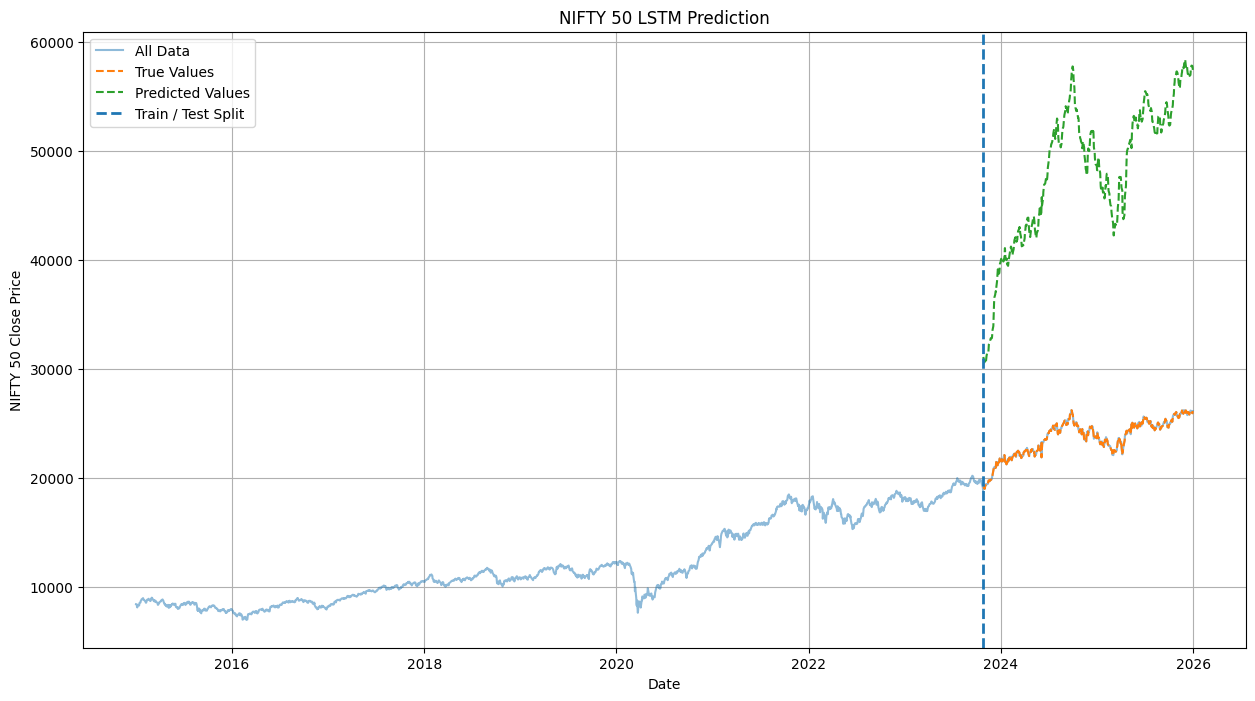

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler


# Download NIFTY 50 data
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close"]].dropna()


# Scale data
scaler = MinMaxScaler()
data = scaler.fit_transform(df)


# Create sequences
look_back = 20
X, y = [], []

for i in range(len(data) - look_back):
    X.append(data[i:i + look_back])
    y.append(data[i + look_back, 3])

X = np.array(X)
y = np.array(y)


# Train-test split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# LSTM model
model = Sequential([
    LSTM(64, input_shape=(look_back, 4)),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


# Train
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(
            monitor="loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)


# Predict
pred = model.predict(X_test, verbose=0).flatten()


# Convert predictions back to original price
temp = np.zeros((len(pred), 4))
temp[:, 3] = pred
pred = scaler.inverse_transform(temp)[:, 3]

temp = np.zeros((len(y_test), 4))
temp[:, 3] = y_test
actual = scaler.inverse_transform(temp)[:, 3]


# Test dates
dates = df.index[split + look_back:]


# Split date
split_date = dates[0]


# Plot
plt.figure(figsize=(15, 8))

# All data
plt.plot(
    df.index,
    df["Close"],
    label="All Data",
    alpha=0.5
)

# True test values
plt.plot(
    dates,
    actual,
    label="True Values",
    linestyle="--"
)

# Predicted values
plt.plot(
    dates,
    pred,
    label="Predicted Values",
    linestyle="--"
)

# Vertical splitting line
plt.axvline(
    x=split_date,
    linestyle="--",
    linewidth=2,
    label="Train / Test Split"
)

plt.xlabel("Date")
plt.ylabel("NIFTY 50 Close Price")

plt.title("NIFTY 50 LSTM Prediction")

plt.legend()
plt.grid(True)

plt.show()

